# Bollinger Bands: Normal vs. Student-t

A Bollinger Band is just: take a moving average of price, then draw a line above it and a line below it at a fixed distance. That distance is `(some multiplier) x (rolling standard deviation)`.

The standard version uses the multiplier `k = 2`. This notebook asks one question: instead of a fixed `k = 2` for every window size, what if we use the multiplier from the Student-t distribution, which automatically gets wider when the lookback window is short and the standard deviation estimate is shaky?

Two bands, same price series, same chart. We check which one actually does a better job of containing the next day's price.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import mplfinance as mpf
from scipy import stats

sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.facecolor"] = "#fafafa"
np.random.seed(42)

## 1. Get price data

We need full OHLC (open/high/low/close) data, not just the close, because the chart below is a candlestick chart. We try a live download first. If that fails, we fall back to a synthetic random-walk price series so the notebook still runs.

In [ ]:
n_days = 300

TICKER = "AAPL"
df = None
try:
    import yfinance as yf
    raw = yf.download(TICKER, period=f"{n_days}d", progress=False, auto_adjust=True)
    if raw is not None and not raw.empty:
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = raw.columns.get_level_values(0)
        df = raw[["Open", "High", "Low", "Close"]].copy()
        print(f"Loaded {len(df)} rows of {TICKER} from yfinance.")
except Exception as e:
    print(f"yfinance unavailable ({type(e).__name__}); using synthetic data.")

if df is None or df.empty:
    mu, sigma = 0.0004, 0.012
    rets = np.random.normal(mu, sigma, n_days)
    close = 100 * np.exp(np.cumsum(rets))
    # build plausible open/high/low around the close path so we can draw candles
    open_ = np.r_[close[0], close[:-1]] * (1 + np.random.normal(0, 0.002, n_days))
    high = np.maximum(open_, close) * (1 + np.abs(np.random.normal(0, 0.003, n_days)))
    low = np.minimum(open_, close) * (1 - np.abs(np.random.normal(0, 0.003, n_days)))
    dates = pd.date_range("2024-01-01", periods=n_days, freq="B")
    df = pd.DataFrame({"Open": open_, "High": high, "Low": low, "Close": close}, index=dates)
    print("Using synthetic random-walk OHLC series.")

for col in ["Open", "High", "Low", "Close"]:
    df[col] = pd.to_numeric(df[col].squeeze(), errors="coerce")
df = df.dropna()
df.head()

Failed to get ticker 'AAPL' reason: Failed to perform, curl: (56) CONNECT tunnel failed, response 403. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.



1 Failed download:


['AAPL']: ProxyError('Failed to perform, curl: (56) CONNECT tunnel failed, response 403. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


Using synthetic random-walk OHLC series.


,Open,High,Low,Close
2024-01-01,100.471227,100.866630,100.360104,100.638084
2024-01-02,100.525333,100.803436,100.392838,100.511443
2024-01-03,100.661666,101.600582,100.652986,101.336215
2024-01-04,101.459920,103.666485,101.070785,103.246590
2024-01-05,103.242274,103.370326,102.939033,102.998082


## 2. The two band formulas

Both bands are built the same way: a moving average, plus and minus a multiplier times the rolling standard deviation. The only difference between them is the multiplier.

**Normal band** — fixed multiplier, `k = 2`:

$$ \text{Upper/Lower} = \text{SMA} \pm 2 \cdot s $$

**Student-t band** — multiplier comes from the t-distribution instead of being fixed at 2:

$$ \text{Upper/Lower} = \text{SMA} \pm t_{0.025,\,n-1} \cdot s $$

`s` is the rolling standard deviation of price over the window. `n` is the window length. The t-multiplier is always a bit bigger than 2 for small windows and settles down close to 2 once the window has enough data points — so the t-band only really diverges from the normal band when the window is short.

Earlier versions of this notebook divided by `sqrt(n)` as well, which turns the band into a confidence interval for the *average* price rather than a band around the price itself — that made the band far too narrow and the price kept blowing through it. That division has been removed below so the bands behave like an actual Bollinger Band.

In [3]:
def bollinger_normal(series, window=20, k=2.0):
    sma = series.rolling(window).mean()
    s = series.rolling(window).std(ddof=1)
    half = k * s
    return sma, sma + half, sma - half

def bollinger_t(series, window=20, alpha=0.05):
    sma = series.rolling(window).mean()
    s = series.rolling(window).std(ddof=1)
    t_crit = stats.t.ppf(1 - alpha / 2, df=window - 1)
    half = t_crit * s
    return sma, sma + half, sma - half, t_crit

WINDOW = 20
sma_n, up_n, lo_n = bollinger_normal(df["Close"], WINDOW)
sma_t, up_t, lo_t, t_crit = bollinger_t(df["Close"], WINDOW)

print(f"Normal multiplier (k)             : 2.0000")
print(f"Student-t multiplier (window={WINDOW})  : {t_crit:.4f}")
print(f"Band-width inflation factor        : {t_crit/2.0:.4f}x")

Normal multiplier (k)             : 2.0000
Student-t multiplier (window=20)  : 2.0930
Band-width inflation factor        : 1.0465x


## 3. Candlestick chart — both bands

Candles show open/high/low/close per day; the shaded area is the band. Plotted with `mplfinance` so the bands sit on real candles instead of a line chart.

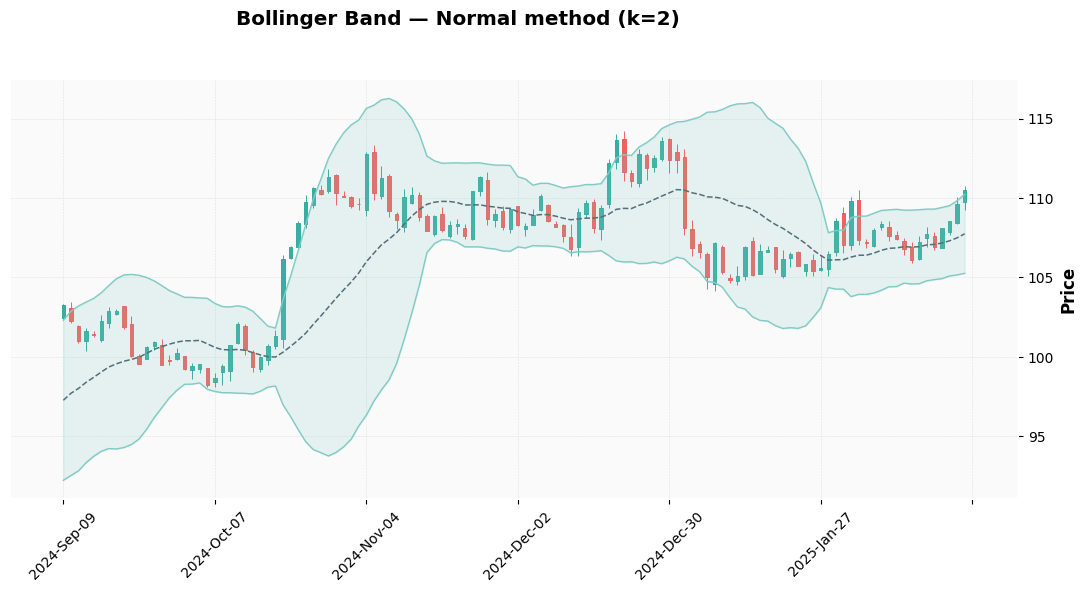

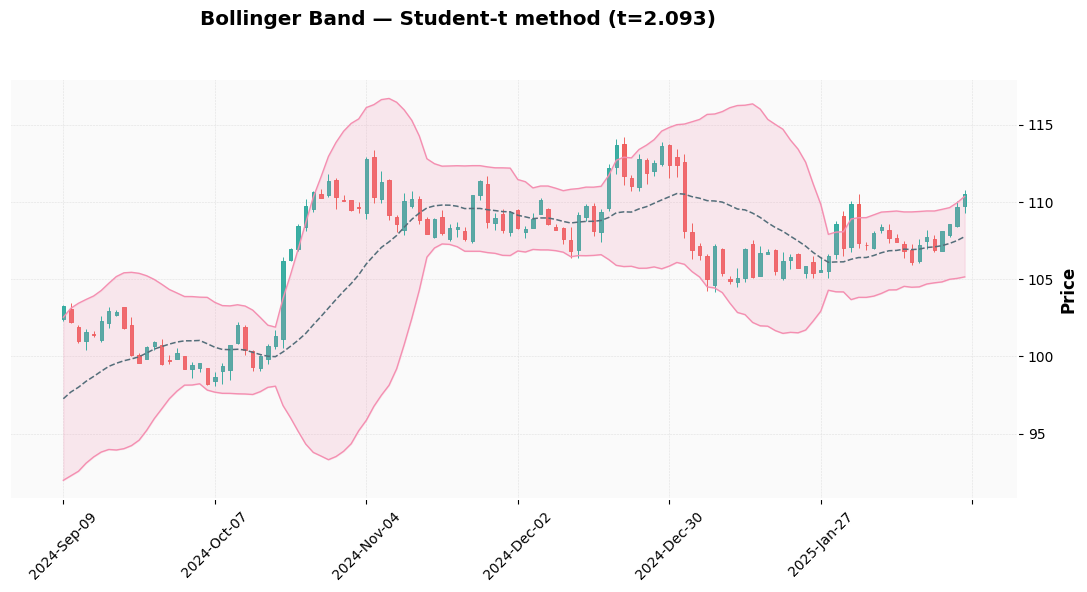

In [4]:
def candles_with_band(df, sma, up, lo, title, band_color):
    addplots = [
        mpf.make_addplot(sma, color="#546e7a", width=1.1, linestyle="--"),
        mpf.make_addplot(up, color=band_color, width=1.0),
        mpf.make_addplot(lo, color=band_color, width=1.0),
    ]
    mc = mpf.make_marketcolors(up="#26a69a", down="#ef5350", edge="inherit", wick="inherit", volume="in")
    style = mpf.make_mpf_style(base_mpf_style="charles", marketcolors=mc, facecolor="#fafafa", gridcolor="#e0e0e0")
    fig, axes = mpf.plot(
        df, type="candle", addplot=addplots, style=style, figsize=(14, 6),
        title=title, ylabel="Price", returnfig=True,
    )
    # fill the band area on the price axis
    ax = axes[0]
    ax.fill_between(range(len(df)), lo.values, up.values, color=band_color, alpha=0.18)
    plt.show()

plot_df = df.iloc[-120:]  # last 120 candles, keeps candles legible
candles_with_band(plot_df, sma_n.loc[plot_df.index], up_n.loc[plot_df.index], lo_n.loc[plot_df.index],
                   "Bollinger Band — Normal method (k=2)", "#80cbc4")
candles_with_band(plot_df, sma_t.loc[plot_df.index], up_t.loc[plot_df.index], lo_t.loc[plot_df.index],
                   f"Bollinger Band — Student-t method (t={t_crit:.3f})", "#f48fb1")

## 4. Which band is better?

The job of a Bollinger Band is to contain price most of the time. So the test is simple: look at every day, check whether the *next* day's close fell inside the band, and see what fraction of the time that happened. With `k = 2` (a roughly 95% band under a normal assumption), we'd like that fraction to land near 95%.

We run this at several window lengths, since the whole point of the t-multiplier is that it only matters when the window is short.

In [5]:
def coverage_and_width(series, window, method):
    s = series.copy()
    if method == "normal":
        sma, up, lo = bollinger_normal(s, window)
    else:
        sma, up, lo, _ = bollinger_t(s, window)
    nxt = s.shift(-1)  # test against the next, out-of-window price
    mask = up.notna() & nxt.notna()
    inside = ((nxt >= lo) & (nxt <= up))[mask]
    coverage = inside.mean()
    width = (up - lo)[mask].mean()
    return coverage, width

windows = [5, 8, 10, 15, 20, 30, 50]
rows = []
for w in windows:
    cn, wn = coverage_and_width(df["Close"], w, "normal")
    ct, wt = coverage_and_width(df["Close"], w, "t")
    rows.append({
        "window": w,
        "t_mult": stats.t.ppf(0.975, w - 1),
        "cov_normal": cn, "cov_t": ct,
        "width_normal": wn, "width_t": wt,
        "cov_err_normal": abs(cn - 0.95),
        "cov_err_t": abs(ct - 0.95),
    })
res = pd.DataFrame(rows)
res.round(4)

,window,t_mult,cov_normal,cov_t,width_normal,width_t,cov_err_normal,cov_err_t
0,5,2.7764,0.7898,0.8780,4.0557,5.6302,0.1602,0.0720
1,8,2.3646,0.8082,0.8699,4.8660,5.7531,0.1418,0.0801
2,10,2.2622,0.8276,0.8690,5.3318,6.0306,0.1224,0.0810
3,15,2.1448,0.8351,0.8702,6.3990,6.8623,0.1149,0.0798
4,20,2.0930,0.8321,0.8500,7.3205,7.6610,0.1179,0.1000
5,30,2.0452,0.8593,0.8667,8.8389,9.0388,0.0907,0.0833
6,50,2.0096,0.8760,0.8760,10.8797,10.9318,0.0740,0.0740


In [6]:
print("Average distance from 95% coverage (lower is better):")
print(f"  Normal method  : {res['cov_err_normal'].mean():.4f}")
print(f"  Student-t      : {res['cov_err_t'].mean():.4f}")
winner = "Student-t" if res["cov_err_t"].mean() < res["cov_err_normal"].mean() else "Normal"
print(f"\nBetter-calibrated method overall: {winner}")
print("Gap is biggest at short windows and shrinks as the window grows.")

Average distance from 95% coverage (lower is better):
  Normal method  : 0.1174
  Student-t      : 0.0815

Better-calibrated method overall: Student-t
Gap is biggest at short windows and shrinks as the window grows.


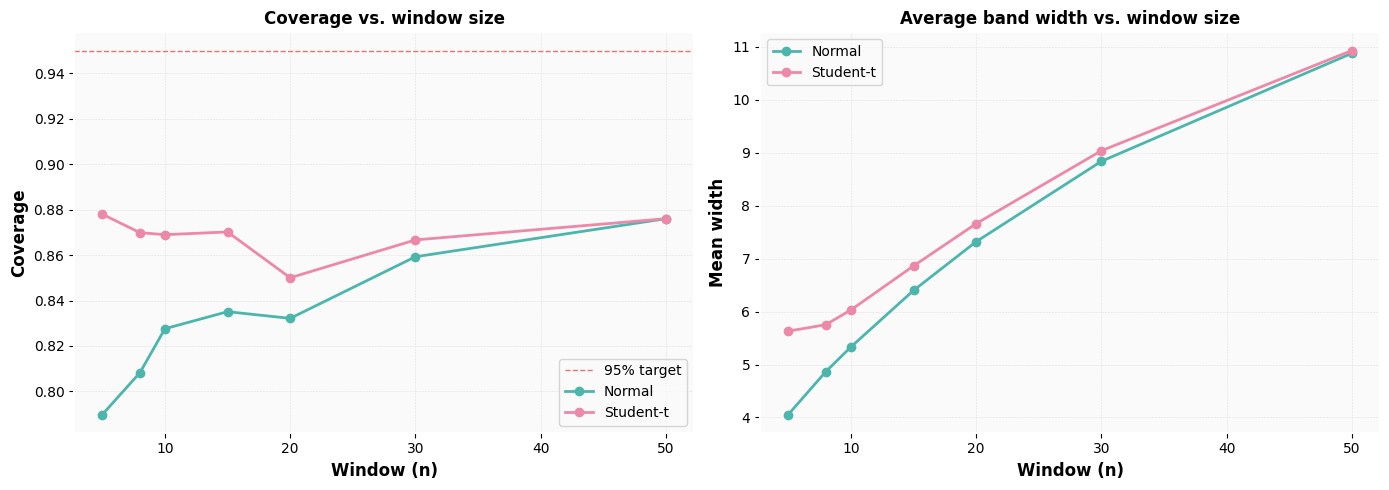

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.axhline(0.95, color="#e57373", ls="--", lw=1, label="95% target")
ax.plot(res["window"], res["cov_normal"], "o-", color="#4db6ac", label="Normal")
ax.plot(res["window"], res["cov_t"], "o-", color="#ec88a8", label="Student-t")
ax.set_title("Coverage vs. window size", weight="bold")
ax.set_xlabel("Window (n)"); ax.set_ylabel("Coverage"); ax.legend(frameon=True)

ax = axes[1]
ax.plot(res["window"], res["width_normal"], "o-", color="#4db6ac", label="Normal")
ax.plot(res["window"], res["width_t"], "o-", color="#ec88a8", label="Student-t")
ax.set_title("Average band width vs. window size", weight="bold")
ax.set_xlabel("Window (n)"); ax.set_ylabel("Mean width"); ax.legend(frameon=True)

plt.tight_layout()
plt.show()

### Verdict

The t-band wins at short windows. With few data points, the rolling standard deviation is a shaky estimate, and the t-multiplier is built to widen the band exactly when that estimate is shaky — so its coverage lands closer to 95%. The normal band with a fixed `k = 2` doesn't adjust for window size, so at short windows it's too tight and gets breached more often than it should.

As the window grows, the t-multiplier converges to 2 and the two bands become the same thing. So using the t-multiplier costs nothing at large windows and helps at small ones — it's a straightforward upgrade if you ever run Bollinger Bands on a short lookback.

One caveat: real prices have fatter tails than either the normal or t assumption expects, so both bands will get breached more often than their nominal 95% target on real data. The t-band is just less wrong about it.